check some defin and concept of classification and regression in notes.

## Downloading MNIST dataset

In [1]:
import numpy as np
import sklearn

In [3]:
from sklearn.datasets import fetch_openml
mnist=fetch_openml(name='mnist_784')
mnist

{'data':        pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  pixel9  \
 0           0       0       0       0       0       0       0       0       0   
 1           0       0       0       0       0       0       0       0       0   
 2           0       0       0       0       0       0       0       0       0   
 3           0       0       0       0       0       0       0       0       0   
 4           0       0       0       0       0       0       0       0       0   
 ...       ...     ...     ...     ...     ...     ...     ...     ...     ...   
 69995       0       0       0       0       0       0       0       0       0   
 69996       0       0       0       0       0       0       0       0       0   
 69997       0       0       0       0       0       0       0       0       0   
 69998       0       0       0       0       0       0       0       0       0   
 69999       0       0       0       0       0       0       0       0       0   
 
      

In [4]:
len(mnist['data'])

70000

## Visualization

In [5]:
X,y=mnist['data'],mnist['target']

In [6]:
X

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
X.shape

(70000, 784)

In [8]:
y

0        5
1        0
2        4
3        1
4        9
        ..
69995    2
69996    3
69997    4
69998    5
69999    6
Name: class, Length: 70000, dtype: category
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

In [9]:
y=y.astype("float")

In [13]:
X.iloc[69999]     #it is raw data, it will return the integers form.

pixel1      0
pixel2      0
pixel3      0
pixel4      0
pixel5      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Name: 69999, Length: 784, dtype: int64

In [14]:
y[69999]

np.float64(6.0)

In [24]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
def viz(n):
    plt.imshow(X.iloc[n].values.reshape(28, 28), cmap='gray')
    plt.show()

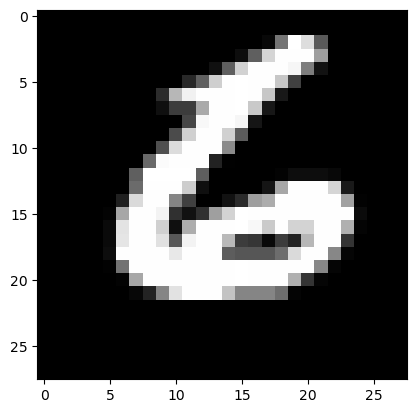

In [25]:
viz(69999) # the raw data is now converted into visualization.

In [26]:
y[1000]

np.float64(0.0)

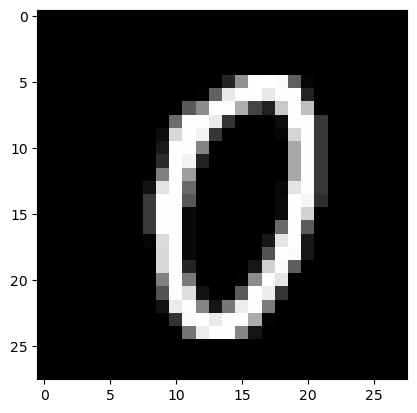

In [27]:
viz(1000)

### Exercise: Locating the number 4 and plot the image

In [28]:
type(y)

pandas.core.series.Series

In [29]:
y==4

0        False
1        False
2         True
3        False
4        False
         ...  
69995    False
69996    False
69997     True
69998    False
69999    False
Name: class, Length: 70000, dtype: bool

In [30]:
np.where(y==4)

(array([    2,     9,    20, ..., 69977, 69987, 69997], shape=(6824,)),)

In [31]:
y[69977]

np.float64(4.0)

In [33]:
def viz(n):
    plt.imshow(X.iloc[n].values.reshape(28, 28), cmap='gray')
    plt.show()

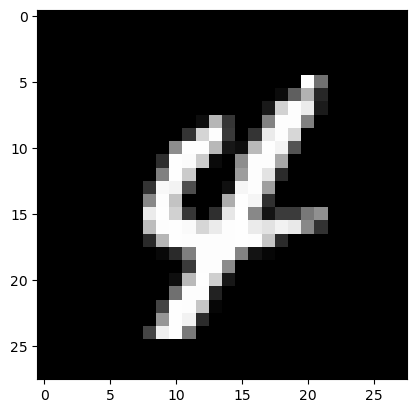

In [35]:
viz(69977)

## Splitting the train and test sets

### Method-1

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,shuffle=True,random_state=42)

### Method-2

In [40]:
num_split=60000
X_train,X_test,y_train,y_test=X[:num_split],X[num_split:],y[:num_split],y[num_split:]

We typically shuffle the training set.This ensure the training set is randomized and your data distribution is considered.
Shuffling is bad idea for time series data.

## Shuffling the dataset

In [41]:
import numpy as np

In [44]:
shuffle_index=np.random.permutation(num_split)
X_train = X_train.iloc[shuffle_index]
y_train = y_train.iloc[shuffle_index]

## Training a Binary Classifier
We need to  convert our target to 0 or non zero

In [48]:
y_train_0=(y_train==0)


In [49]:
y_train_0

5825     False
25935    False
21390    False
32041    False
49589    False
         ...  
8822     False
13507    False
33041    False
34408    False
11555    False
Name: class, Length: 60000, dtype: bool

In [50]:
y_test_0=(y_test==0)

In [51]:
y_test_0

60000    False
60001    False
60002    False
60003     True
60004    False
         ...  
69995    False
69996    False
69997    False
69998    False
69999    False
Name: class, Length: 10000, dtype: bool

---
# SGDClassifier

SGDClassifier Linear classifiers(SVM,logistic regression) with SGD training.

## Training

In [52]:
from sklearn.linear_model import SGDClassifier

clf=SGDClassifier(random_state=0)
clf.fit(X_train,y_train_0)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


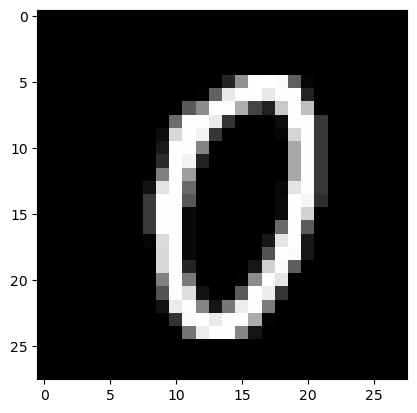

In [53]:
viz(1000)

In [59]:
clf.predict(X.iloc[[1000]])

array([ True])

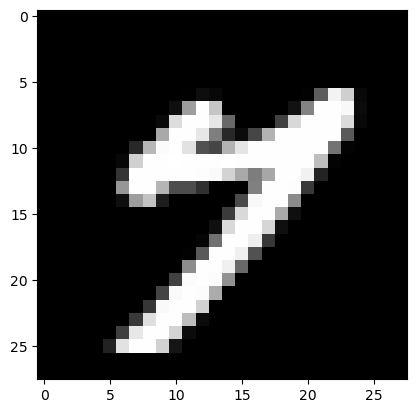

In [60]:
viz(1001)

In [62]:
clf.predict(X.iloc[[1001]])

array([False])

# Performance Measures
## Measuring Accuracy using Cross-Validation
### StratifiedKFold

In [77]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
clf=SGDClassifier(random_state=0)

In [78]:
skfolds=StratifiedKFold(n_splits=3, random_state=100,shuffle=True)

In [82]:
for train_index,test_index in skfolds.split(X_train,y_train_0):
    clone_clf=clone(clf)
    X_train_fold=X_train.iloc[train_index]
    y_train_fold=(y_train_0.iloc[train_index])
    X_test_fold=X_train.iloc[test_index]
    y_test_fold=(y_train_0.iloc[test_index])

    clone_clf.fit(X_train_fold,y_train_fold)
    y_pred=clone_clf.predict(X_test_fold)
    n_correct=sum(y_pred==y_test_fold)
    print("{0:.4f}".format(n_correct/len(y_pred)))

0.9870
0.9879
0.9800


### cross_val_score using K-Fold Cross-Validation
K-Fold cross-validation splits the training set into K-Folds and then make predictions and evaluate then on each fold using a model trained on the remaining folds.

In [83]:
from sklearn.model_selection import cross_val_score

In [84]:
cross_val_score(clf,X_train,y_train_0,cv=3,scoring='accuracy')

array([0.9887 , 0.98765, 0.98645])

Better to use cross_val_score method 
Easy and simple code.

## Confusion Matrix

In [85]:
from sklearn.model_selection import cross_val_predict

In [87]:
y_train_pred=cross_val_predict(clf, X_train,y_train_0,cv=3)

In [90]:
from sklearn.metrics import confusion_matrix

In [91]:
confusion_matrix(y_train_0,y_train_pred)

array([[53712,   365],
       [  379,  5544]])

In [92]:
import pandas as pd
pd.DataFrame(confusion_matrix(y_train_0,y_train_pred))

,0,1
0,53712,365
1,379,5544


In [94]:
pd.DataFrame(confusion_matrix(y_train_0,y_train_pred),
             columns=pd.MultiIndex.from_product([['Prediction'],["Negative","Positive"]]),
             index=pd.MultiIndex.from_product([["Actual"],["Negative","Positive"]]))

Prediction         
                  Negative Positive
Actual Negative      53712      365
       Positive        379     5544

In [103]:
5550/(365+5550)   #it is based on the below formula substitution value.
# it will be same as below output of the code. For Precision

0.9382924767540152

In [104]:
5550/(373+5550)   # For Recall same as above calculated one

0.9370251561708594

## Precision
measures the accuracy of positive predictions.

In [105]:
from sklearn.metrics import precision_score, recall_score

Note that result here may vary from the video as the results from the confusion matrix are different each time you run it

In [106]:
precision_score(y_train_0,y_train_pred)

0.9382298189202911

## Recall
precision is typpically used with recall(Sensitivity or True Positive Rate). The ratio of Positive instances that are correctly detected by the clasifier.

Note that result here may vary from the video as the results from the confusion matrix are different each time you run it

In [107]:
recall_score(y_train_0,y_train_pred)

0.936012156002026

## F1 Score
The F1 score favours classifiers that have similar precision and recall

In [108]:
from sklearn.metrics import f1_score

Note that result here may vary from the video as the results from the confusion matrix are different each time you run it

In [109]:
f1_score(y_train_0,y_train_pred)

0.9371196754563894

---

## Precision/ Recall Tradeoff
increasing precsion reduced recall and vice-versa

In [110]:
np.random.seed(0)
clf=SGDClassifier(random_state=0)
clf.fit(X_train,y_train_0)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [111]:
y[1000]

np.float64(0.0)

In [113]:
y_scores=clf.decision_function(X.iloc[[1000]])
y_scores

array([8809.0706242])

In [114]:
y[1001]

np.float64(7.0)

In [117]:
y_scores=clf.decision_function(X.iloc[[1001]])
y_scores

array([-33343.70929217])

In [118]:
threshold=0

In [119]:
y_some_digits_pred=(y_scores>threshold)

In [120]:
y_some_digits_pred

array([False])

In [121]:
threshold=40000
y_some_digits_pred=(y_scores>threshold)
y_some_digits_pred

array([False])

In [122]:
y_scores=cross_val_predict(clf,X_train,y_train,cv=3,method='decision_function')

(array([5.000e+00, 2.000e+00, 7.000e+00, 1.000e+01, 2.700e+01, 3.600e+01,
        6.700e+01, 9.500e+01, 1.460e+02, 2.220e+02, 2.590e+02, 3.850e+02,
        4.220e+02, 4.660e+02, 5.300e+02, 5.450e+02, 5.500e+02, 5.300e+02,
        4.280e+02, 3.330e+02, 2.820e+02, 2.730e+02, 2.360e+02, 3.050e+02,
        4.210e+02, 4.880e+02, 7.420e+02, 9.130e+02, 1.285e+03, 1.530e+03,
        1.858e+03, 2.179e+03, 2.474e+03, 2.649e+03, 2.723e+03, 2.875e+03,
        2.803e+03, 2.750e+03, 2.744e+03, 2.590e+03, 2.391e+03, 2.287e+03,
        2.070e+03, 1.874e+03, 1.711e+03, 1.576e+03, 1.395e+03, 1.265e+03,
        1.153e+03, 9.650e+02, 8.830e+02, 7.710e+02, 6.520e+02, 5.890e+02,
        4.690e+02, 4.110e+02, 3.570e+02, 2.830e+02, 2.760e+02, 2.190e+02,
        1.880e+02, 1.730e+02, 1.320e+02, 1.240e+02, 9.000e+01, 8.200e+01,
        6.100e+01, 5.100e+01, 5.300e+01, 4.300e+01, 3.000e+01, 3.000e+01,
        2.500e+01, 1.900e+01, 2.200e+01, 1.300e+01, 6.000e+00, 1.300e+01,
        1.100e+01, 7.000e+00, 1.000e+0

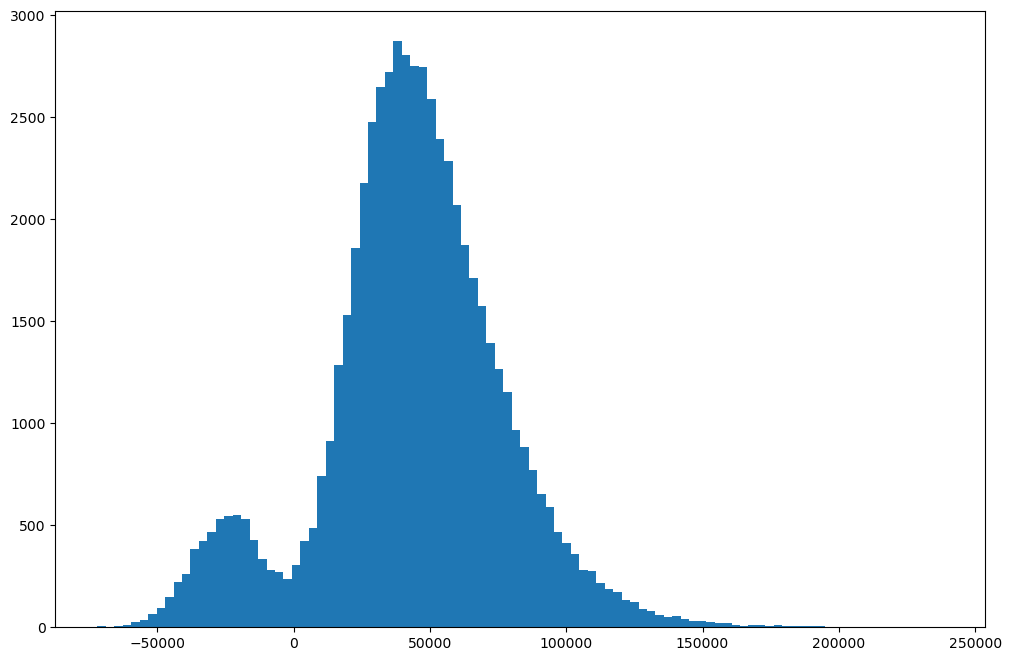

In [123]:
plt.figure(figsize=(12,8))
plt.hist(y_scores,bins=100)

With decision scores,we can compute precision and recall for all possible thresholds using the precision_recall_curve() function.

In [124]:
from sklearn.metrics import precision_recall_curve

In [126]:
precisions,recalls,thresholds=precision_recall_curve(y_train_0,y_scores)

In [129]:
def plot_precision_recall_vs_threshold(precisions,recalls,thresholds):
    plt.plot(thresholds,precisions[:-1],"b--",label="Precision")
    plt.plot(thresholds,recalls[:-1],"g--",label="Recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.ylim([0,1])

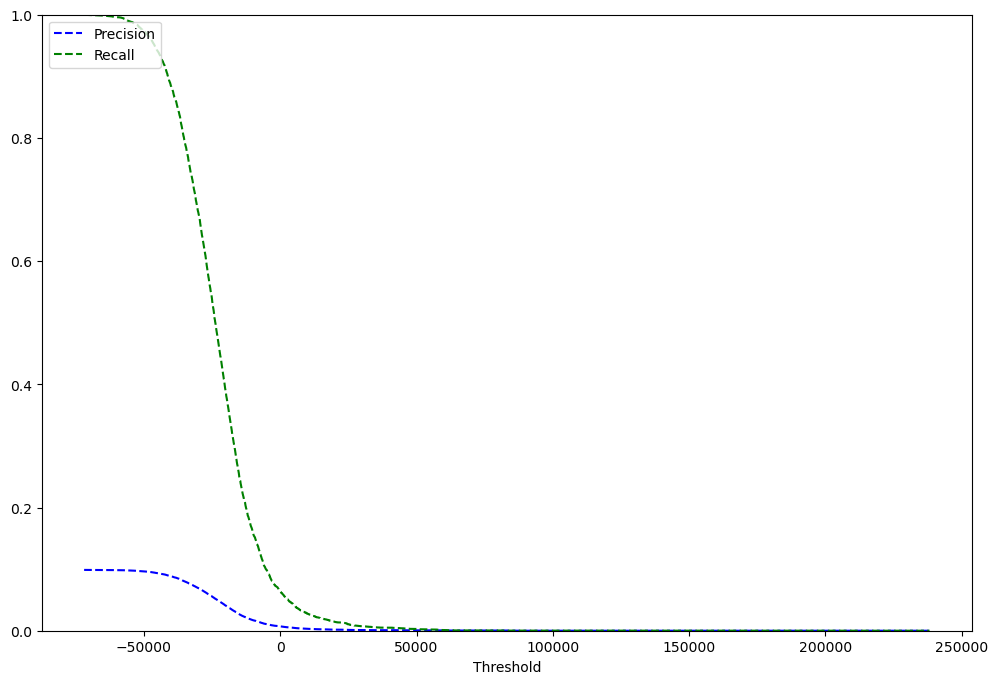

In [130]:
plt.figure(figsize=(12,8))
plot_precision_recall_vs_threshold(precisions,recalls,thresholds)
plt.show()

---

Text(0.5, 1.0, 'PR Curve: Precisions/recalls tradeoff')

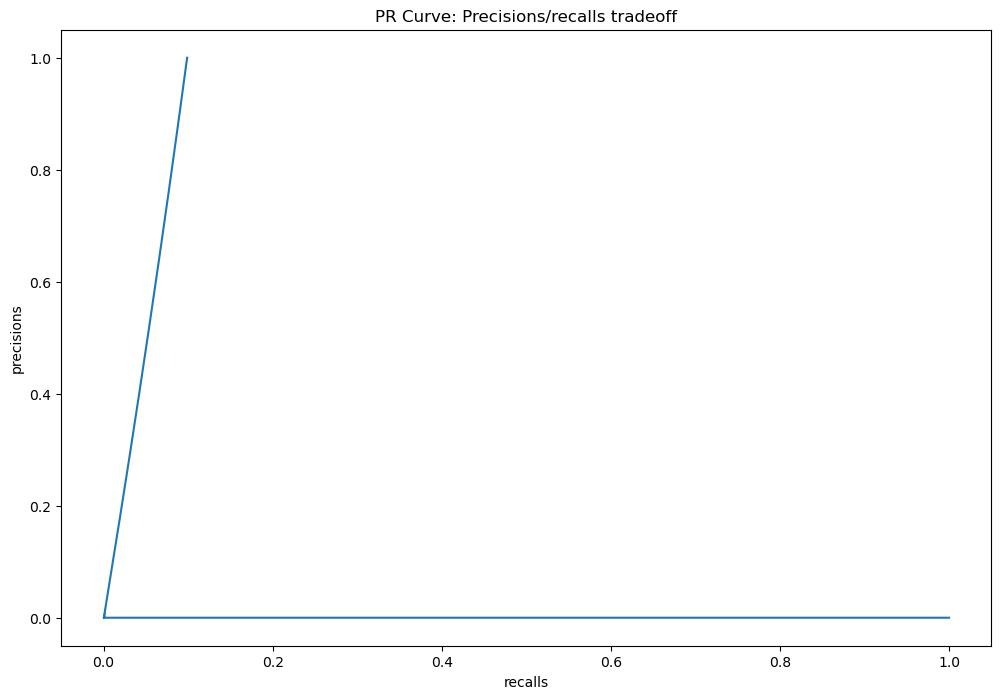

In [131]:
plt.figure(figsize=(12,8))
plt.plot(precisions,recalls)
plt.xlabel("recalls")
plt.ylabel("precisions")
plt.title("PR Curve: Precisions/recalls tradeoff")

## Setting High Precisions

In [133]:
len(precisions)

60001

In [134]:
len(thresholds)

60000

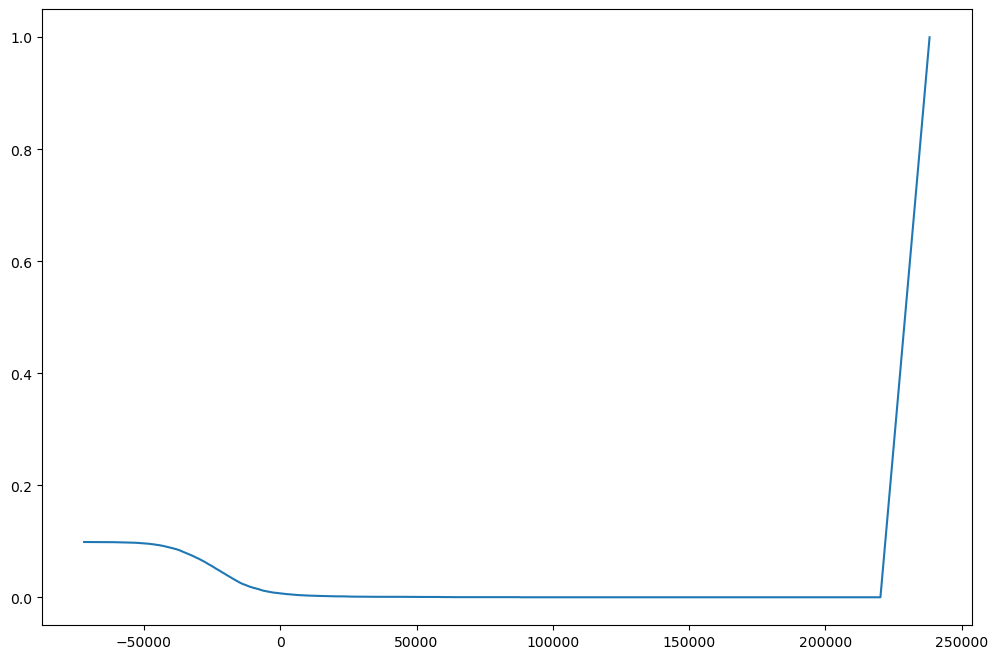

In [135]:
plt.figure(figsize=(12,8))
plt.plot(thresholds,precisions[1:])

In [144]:
idx=len(precisions[precisions<0.9])

In [145]:
thresholds[idx]

IndexError: index 60000 is out of bounds for axis 0 with size 60000

In [143]:
y_scores_pred_90=(y_scores>thresholds[idx])

IndexError: index 60000 is out of bounds for axis 0 with size 60000

In [146]:
# verify once because it getting errors.

---
## ROC

In [147]:
from sklearn.metrics import roc_curve

In [148]:
fpr,tpr,thresholds=roc_curve(y_train_0,y_scores)

In [149]:
def plot_roc_curve(fpr,tpr,label=None):
    plt.plot(fpr,tpr,linewidth=2,label=label)
    plt.plot([0,1],[0,1],'k--')
    plt.axis([0,1,0,1])
    plt.xlabel("false Positive rate")
    plt.ylabel("true Positive rate")
    plt.title("ROC Curve")

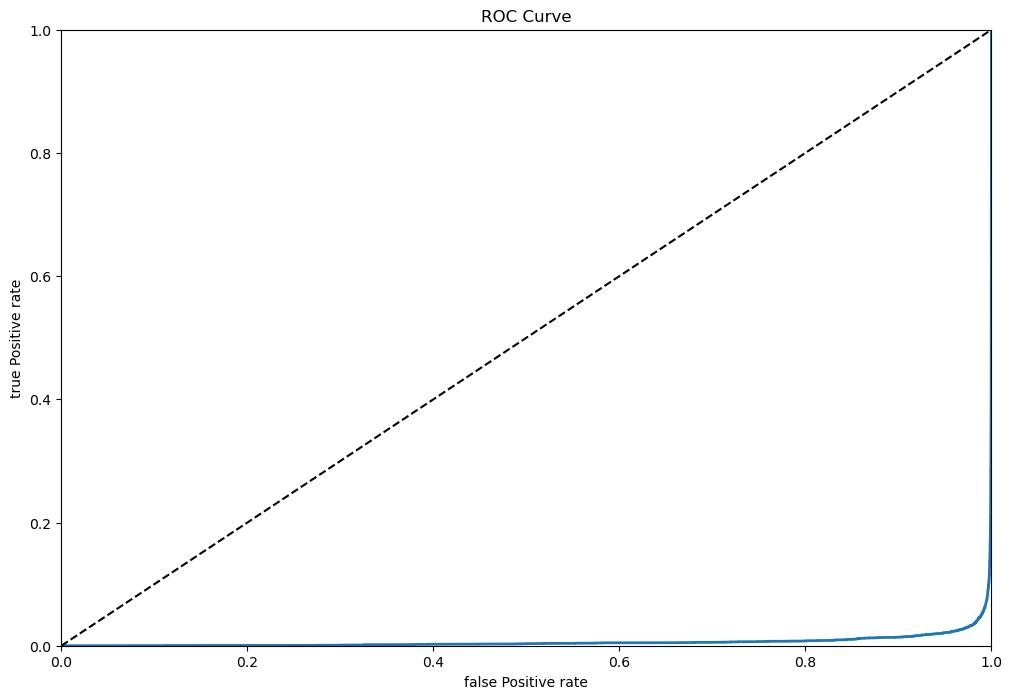

In [150]:
plt.figure(figsize=(12,8))
plot_roc_curve(fpr,tpr)
plt.show()

In [151]:
from sklearn.metrics import roc_auc_score

In [152]:
roc_auc_score(y_train_0,y_scores)

0.006345317640080324

## Model Comparision
### Random Forest

In [153]:
from sklearn.ensemble import RandomForestClassifier

In [155]:
f_clf=RandomForestClassifier(random_state=0,n_estimators=100)

In [156]:
y_probas_forest=cross_val_predict(f_clf,X_train,y_train_0,
                                  cv=3,method='predict_proba')

In [157]:
y_scores_forest=y_probas_forest[:,-1]
fpr_forest,tpr_forest,threshold_forest=roc_curve(y_train_0,y_scores_forest)

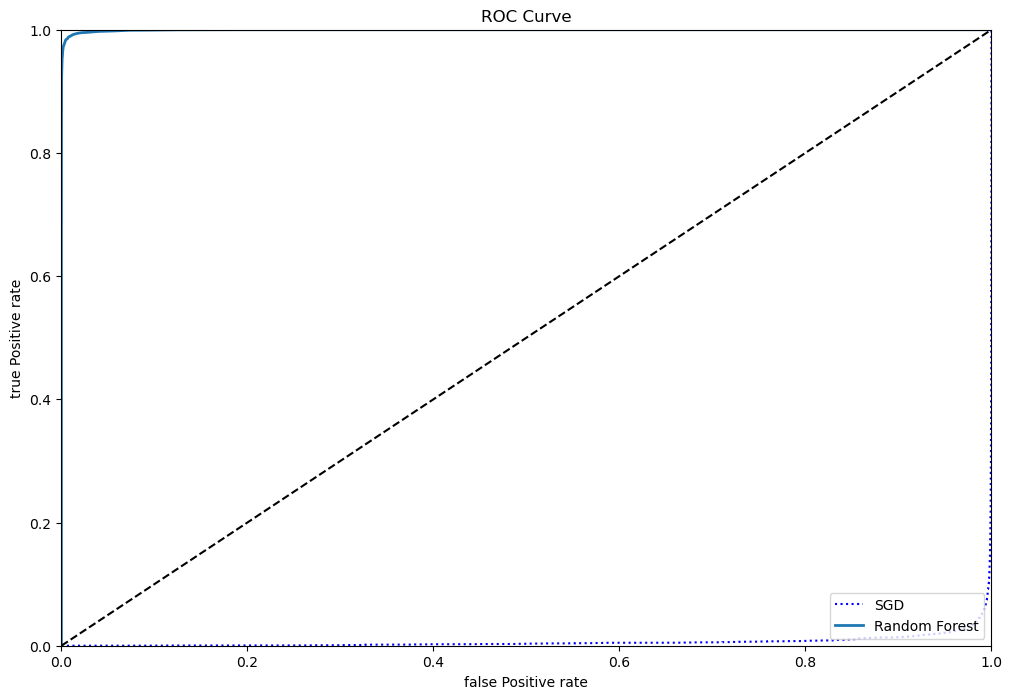

In [159]:
plt.figure(figsize=(12,8))
plt.plot(fpr,tpr,"b:",label="SGD")
plot_roc_curve(fpr_forest,tpr_forest,"Random Forest")
plt.legend(loc="lower right")
plt.show()

In [160]:
roc_auc_score(y_train_0,y_scores_forest)

0.9995041009784914

In [161]:
f_clf.fit(X_train,y_train_0)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [162]:
y_train_rf=cross_val_predict(f_clf,X_train,y_train_0,cv=3)

In [163]:
precision_score(y_train_0,y_train_rf)

0.9931058865122857

In [164]:
recall_score(y_train_0,y_train_rf)

0.9485058247509708

In [165]:
confusion_matrix(y_train_0,y_train_rf)

array([[54038,    39],
       [  305,  5618]])

---